In [1]:
from keras.preprocessing.image import load_img , img_to_array 
import os 
import numpy as np 
import matplotlib.pyplot as pt
from tensorflow.keras.callbacks import ModelCheckpoint 
import keras as kt 
import tensorflow as tf
from keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kerastuner as ktu

2026-03-08 04:08:31.452257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772942911.642803      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772942911.694551      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772942912.128024      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772942912.128065      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772942912.128068      55 computation_placer.cc:177] computation placer alr

In [2]:
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import  Conv2D ,  Flatten , Dense   , MaxPooling2D , BatchNormalization , Dropout , LeakyReLU 

In [ ]:
gen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [4]:
dataset = gen.flow_from_directory(directory = r'/kaggle/input/datasets/tongpython/cat-and-dog/training_set/training_set' , 
                                 target_size = (  150 , 150  ) , color_mode = 'rgb' , 
                                 class_mode = 'binary' ,
                                 save_format = '.jpg' ,
                                  batch_size = 200, 
                                  shuffle = True 
                                 )

Found 8005 images belonging to 2 classes.


In [5]:
testing_dataset = kt.utils.image_dataset_from_directory(
    directory = r'/kaggle/input/datasets/tongpython/cat-and-dog/test_set/test_set',
    labels = 'inferred',
    label_mode='binary',
    image_size= (  150   ,   150   ),
    shuffle = True ,
    batch_size=          200 ,
    color_mode   = 'rgb'
)

Found 2023 files belonging to 2 classes.


I0000 00:00:1772942973.619092      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772942973.625095      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
#  normalise 
def image_process ( image , label ):
    image =  tf.cast ( image /  255 , dtype='float32' )
    return image , label 
test_set = testing_dataset.map ( image_process)

In [7]:
#  scratch 
model= Sequential() 
model.add ( Conv2D(filters =            100        , kernel_size = ( 3 , 3 ) , activation  = LeakyReLU (alpha = 0.001 ) , input_shape = ( 150 , 150 , 3 )  ))
model.add ( MaxPooling2D( strides = 2 , pool_size = (  2, 2  )))
model.add ( Conv2D(filters =             50          , kernel_size = ( 3 , 3 ) , activation  = LeakyReLU (alpha = 0.001 ) ) )
model.add ( MaxPooling2D( strides = 2 , pool_size = (  2 , 2 )))
model.add( Flatten() )
model.add ( Dense (      200 , activation = LeakyReLU (alpha = 0.001 ) ))
model.add ( Dense (  100  , activation = LeakyReLU (alpha = 0.001 ) ))
model.add ( Dense (    100  , activation = LeakyReLU (alpha = 0.001 ) ))
model.add ( Dense (   100 , activation = LeakyReLU (alpha = 0.001 ) ))


model.add ( Dense ( 1 , activation = 'sigmoid' ))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 100)  │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 50)     │        45,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │    12,960,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,048,451 (49.78 MB)

 Trainable params: 13,048,451 (49.78 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile ( loss = 'binary_crossentropy' , optimizer= 'adam' , metrics = ['accuracy'] )

In [10]:
history = model.fit (   dataset  , validation_data  = test_set , epochs =     50      )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1772943003.798372     183 service.cc:152] XLA service 0x318fc520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772943003.798414     183 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772943003.798434     183 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772943004.293394     183 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-08 04:10:11.047145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 04:10:11.273272: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1772943017.471205     183 device_compil

30/41 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5048 - loss: 0.7192

2026-03-08 04:11:29.406862: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 04:11:29.554934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


41/41 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.5088 - loss: 0.7136 - val_accuracy: 0.5739 - val_loss: 0.6917
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5515 - loss: 0.6966 - val_accuracy: 0.5764 - val_loss: 0.6889
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5953 - loss: 0.6753 - val_accuracy: 0.5952 - val_loss: 0.6651
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6266 - loss: 0.6620 - val_accuracy: 0.6673 - val_loss: 0.6279
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6332 - loss: 0.6405 - val_accuracy: 0.6678 - val_loss: 0.6222
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6608 - loss: 0.6214 - val_accuracy: 0.6688 - val_loss: 0.6136
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.6566 - loss: 0.6156 - val_accuracy: 0.5487 - val_loss: 0.6829
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6502 - loss: 0.6201 - val_accuracy: 0.6901 - val_loss: 0.6109
Ep

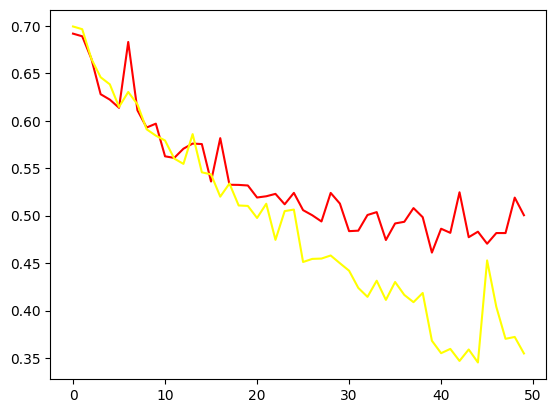

In [11]:
pt.plot ( history.history['val_loss'] , color = 'red')
pt.plot ( history.history['loss'] , color = 'yellow')
pt.show() 

In [12]:
history = model.fit (   dataset  , validation_data  = test_set , epochs =      20       )

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.8308 - loss: 0.3767 - val_accuracy: 0.7870 - val_loss: 0.5108
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8539 - loss: 0.3399 - val_accuracy: 0.7944 - val_loss: 0.5145
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8526 - loss: 0.3227 - val_accuracy: 0.7978 - val_loss: 0.4824
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8720 - loss: 0.2963 - val_accuracy: 0.7825 - val_loss: 0.5236
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8702 - loss: 0.3069 - val_accuracy: 0.7771 - val_loss: 0.5497
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8646 - loss: 0.3055 - val_accuracy: 0.7815 - val_loss: 0.5072
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8669 - loss: 0.3041 - val_accuracy: 0.7484 - val_loss: 0.7124
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8265 - loss: 0.3766 - val_accuracy: 0.7771 - val_loss:

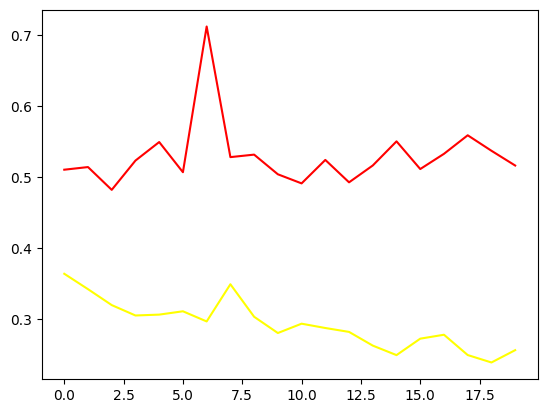

In [13]:
pt.plot ( history.history['val_loss'] , color = 'red')
pt.plot ( history.history['loss'] , color = 'yellow')
pt.show() 